# MiniJEPA with ResNet18 + Strong Decoder (Google Colab)

This notebook trains MiniJEPA using:
- **Encoder**: ResNet18 pretrained on ImageNet
- **Decoder**: StrongPatchDecoder with transposed convolutions
- **Dataset**: CIFAR-10 (auto-downloaded)

**Output**: Downloads `mini_jepa_pretrained.pt` checkpoint (~50MB)

In [1]:
!pip install -q torch torchvision tqdm matplotlib "pillow>=10.1.0,<11.0.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 68.2 MB/s eta 0:00:00a 0:00:01


In [2]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from tqdm.notebook import tqdm

# Configuration
SEED = 42
DATA_DIR = "./data"
OUTPUT_DIR = "./outputs"
DATASET = "cifar10"
EPOCHS = 20
BATCH_SIZE = 256
LR = 5e-4
EMBEDDING_DIM = 512
PATCH_SIZE = 8
EMA = 0.99
RECON_WEIGHT = 0.5

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def get_device() -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

set_seed(SEED)
device = get_device()
print(f"Device: {device}")
print(f"CUDA Available: {torch.cuda.is_available()}")

Device: cuda
CUDA Available: True


## Model Definitions

In [3]:
class PretrainedEncoder(nn.Module):
    """ResNet18 encoder pretrained on ImageNet, adapted for 32x32 images."""
    
    def __init__(self, embedding_dim: int = 512):
        super().__init__()
        # Load pretrained ResNet18
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        
        # Adapt for 32x32 images
        resnet.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        resnet.maxpool = nn.Identity()  # Remove maxpool
        
        # Keep all layers except final FC
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        
        # Projection head
        self.proj = nn.Sequential(
            nn.Flatten(),
            nn.Linear(resnet.fc.in_features, embedding_dim),
            nn.LayerNorm(embedding_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.proj(self.backbone(x))


class JEPAEmbeddingPredictor(nn.Module):
    """Predicts embedding from context embedding and mask features."""
    
    def __init__(self, embedding_dim: int = 512, hidden_dim: int = 512, mask_feat_dim: int = 4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embedding_dim + mask_feat_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, embedding_dim),
        )

    def forward(self, context_embedding: torch.Tensor, mask_features: torch.Tensor) -> torch.Tensor:
        return self.net(torch.cat([context_embedding, mask_features], dim=1))


class ResidualBlock(nn.Module):
    """Residual convolutional block."""
    
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int = 3, padding: int = 1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size, padding=padding)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.gelu = nn.GELU()
        self.skip = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = self.skip(x)
        out = self.gelu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.gelu(out + residual)


class StrongPatchDecoder(nn.Module):
    """Strong convolutional decoder with ResBlocks for high-quality patch reconstruction."""
    
    def __init__(self, embedding_dim: int = 512, out_channels: int = 3, patch_size: int = 8):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.out_channels = out_channels
        self.patch_size = patch_size
        
        # Project embedding to 4x4 feature map
        self.initial_proj = nn.Linear(embedding_dim, 256 * 4 * 4)
        self.initial_bn = nn.BatchNorm1d(256 * 4 * 4)
        
        # Residual blocks
        self.res_block1 = ResidualBlock(256, 256, kernel_size=3, padding=1)
        
        # Upsample 4x4 -> 8x8
        self.upsample1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),
        )
        self.res_block2 = ResidualBlock(128, 128, kernel_size=3, padding=1)
        
        # Output
        self.final_conv = nn.Conv2d(128, out_channels, kernel_size=3, padding=1)

    def forward(self, embedding: torch.Tensor) -> torch.Tensor:
        batch_size = embedding.shape[0]
        
        # Project to feature map
        x = self.initial_proj(embedding)
        x = torch.nn.functional.gelu(self.initial_bn(x))
        x = x.view(batch_size, 256, 4, 4)
        
        # Refine
        x = self.res_block1(x)
        
        # Upsample
        x = self.upsample1(x)
        x = self.res_block2(x)
        
        # Output
        x = self.final_conv(x)
        x = torch.clamp(x, -1.0, 1.0)
        
        return x

## Utilities

In [4]:
def get_dataloaders(data_dir: str, batch_size: int):
    """Load CIFAR-10 with ImageNet normalization."""
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ])
    train_set = datasets.CIFAR10(data_dir, train=True, download=True, transform=transform)
    test_set = datasets.CIFAR10(data_dir, train=False, download=True, transform=transform)
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=0)
    return train_loader, test_loader


def random_mask_batch(images: torch.Tensor, patch_size: int):
    """Randomly mask patches and return (masked_img, target_patch, mask_features)."""
    b, c, h, w = images.shape
    masked = images.clone()
    patches = torch.zeros((b, c, patch_size, patch_size), device=images.device)
    mask_features = torch.zeros((b, 4), device=images.device)

    FILL_VALUE = -1.0  # Black in ImageNet-normalized space

    for i in range(b):
        top = torch.randint(0, h - patch_size + 1, (1,), device=images.device).item()
        left = torch.randint(0, w - patch_size + 1, (1,), device=images.device).item()
        patches[i] = images[i, :, top:top + patch_size, left:left + patch_size]
        masked[i, :, top:top + patch_size, left:left + patch_size] = FILL_VALUE
        mask_features[i] = torch.tensor(
            [left / max(1, w - 1), top / max(1, h - 1), patch_size / w, patch_size / h],
            device=images.device,
        )
    return masked, patches, mask_features


def update_ema(target_model: nn.Module, source_model: nn.Module, momentum: float = 0.99) -> None:
    """Update target encoder with exponential moving average."""
    with torch.no_grad():
        for p_t, p_s in zip(target_model.parameters(), source_model.parameters()):
            p_t.data = momentum * p_t.data + (1.0 - momentum) * p_s.data

## Training

In [5]:
# Load data
train_loader, test_loader = get_dataloaders(DATA_DIR, BATCH_SIZE)
print(f"✓ CIFAR-10 loaded: {len(train_loader)} train batches, {len(test_loader)} test batches")

100%|██████████| 170M/170M [19:07<00:00, 149kB/s]  


✓ CIFAR-10 loaded: 196 train batches, 40 test batches


In [6]:
# Initialize models
context_encoder = PretrainedEncoder(embedding_dim=EMBEDDING_DIM).to(device)
target_encoder = PretrainedEncoder(embedding_dim=EMBEDDING_DIM).to(device)
predictor = JEPAEmbeddingPredictor(embedding_dim=EMBEDDING_DIM).to(device)
decoder = StrongPatchDecoder(embedding_dim=EMBEDDING_DIM, out_channels=3, patch_size=PATCH_SIZE).to(device)

# Copy weights to target encoder and freeze
target_encoder.load_state_dict(context_encoder.state_dict())
for p in target_encoder.parameters():
    p.requires_grad = False

print(f"✓ Models initialized")
print(f"  Context Encoder params: {sum(p.numel() for p in context_encoder.parameters()):,}")
print(f"  Predictor params: {sum(p.numel() for p in predictor.parameters()):,}")
print(f"  Strong Decoder params: {sum(p.numel() for p in decoder.parameters()):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 123MB/s] 


✓ Models initialized
  Context Encoder params: 11,432,512
  Predictor params: 790,016
  Strong Decoder params: 4,114,435


In [7]:
# Loss and optimizer
emb_criterion = nn.MSELoss()
recon_criterion = nn.MSELoss()
optimizer = optim.Adam(
    list(context_encoder.parameters()) + 
    list(predictor.parameters()) + 
    list(decoder.parameters()),
    lr=LR
)

print(f"✓ Optimizer initialized (LR={LR})")

✓ Optimizer initialized (LR=0.0005)


In [8]:
# Training loop
epoch_losses = []

for epoch in range(1, EPOCHS + 1):
    context_encoder.train()
    predictor.train()
    decoder.train()
    
    running_loss = 0.0
    progress = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")
    
    for images, _ in progress:
        images = images.to(device)
        
        # Create masked batch
        masked_images, target_patches, mask_features = random_mask_batch(images, patch_size=PATCH_SIZE)
        
        # Forward pass
        context_embedding = context_encoder(masked_images)
        pred_embedding = predictor(context_embedding, mask_features)
        
        with torch.no_grad():
            target_embedding = target_encoder(target_patches)
        
        pred_patch = decoder(pred_embedding)
        
        # Loss
        emb_loss = emb_criterion(pred_embedding, target_embedding)
        recon_loss = recon_criterion(pred_patch, target_patches)
        loss = emb_loss + RECON_WEIGHT * recon_loss
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Update EMA target encoder
        update_ema(target_encoder, context_encoder, momentum=EMA)
        
        running_loss += loss.item()
        progress.set_postfix(loss=f"{loss.item():.6f}")
    
    avg_loss = running_loss / len(train_loader)
    epoch_losses.append(avg_loss)
    print(f"Epoch {epoch}: Loss={avg_loss:.6f}")

Epoch 1/20:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 1: Loss=0.570014


Epoch 2/20:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 2: Loss=0.288427


Epoch 3/20:   0%|          | 0/196 [00:00<?, ?it/s]

...

Epoch 18: Loss=0.232026


Epoch 19/20:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 19: Loss=0.228403


Epoch 20/20:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 20: Loss=0.226813


## Save Checkpoint

In [12]:
# Save checkpoint
checkpoint = {
    "context_encoder": context_encoder.state_dict(),
    "predictor": predictor.state_dict(),
    "decoder": decoder.state_dict(),
    "dataset": DATASET,
    "patch_size": PATCH_SIZE,
    "embedding_dim": EMBEDDING_DIM,
    "channels": 3,
    "epochs": EPOCHS,
    "final_loss": epoch_losses[-1],
    "losses": epoch_losses,
}

checkpoint_path = os.path.join(OUTPUT_DIR, "mini_jepa_pretrained.pt")
torch.save(checkpoint, checkpoint_path)
print(f"✓ Checkpoint saved: {checkpoint_path}")
print(f"  File size: {os.path.getsize(checkpoint_path) / 1e6:.1f} MB")
print(f"  Final loss: {epoch_losses[-1]:.6f}")

✓ Checkpoint saved: ./outputs/mini_jepa_pretrained.pt
  File size: 65.5 MB
  Final loss: 0.226813


## Download Checkpoint

In [13]:
# Download the checkpoint
from google.colab import files

print("Downloading checkpoint...")
files.download(checkpoint_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Example of a Reconstructed Image

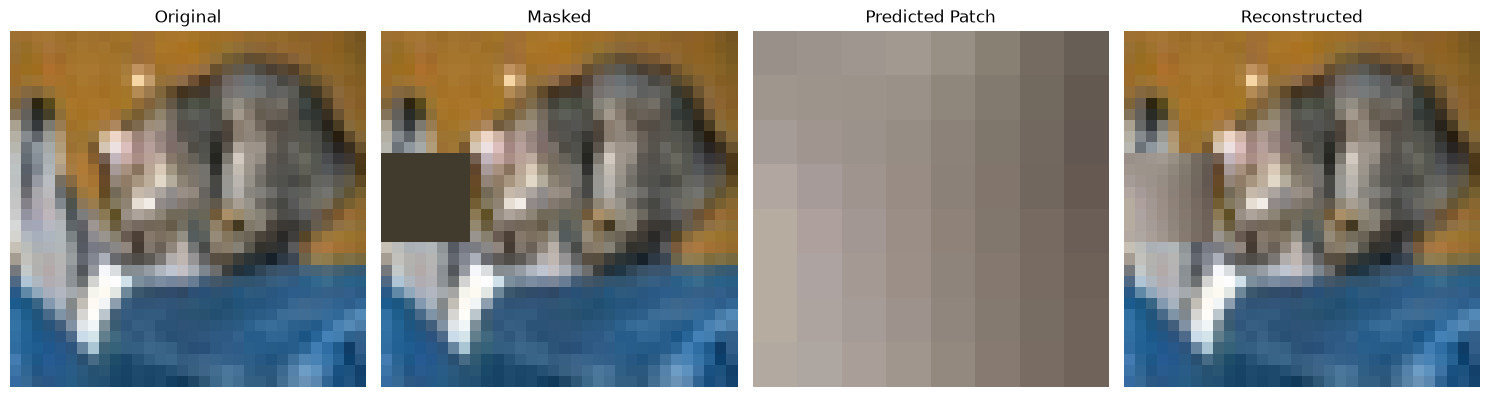

Mask placed at: top=11, left=0
Patch range: [-1.000, 1.000]


In [20]:
# Test inference with EXACT coordinates
context_encoder.eval()
predictor.eval()
decoder.eval()

import matplotlib.pyplot as plt

with torch.no_grad():
    test_images, _ = next(iter(test_loader))
    test_images = test_images.to(device)

    # --- Mask manually so we keep EXACT pixel coords ---
    b, c, h, w = test_images.shape
    FILL_VALUE = -1.0
    masked_images = test_images.clone()
    mask_features = torch.zeros((b, 4), device=device)

    exact_tops  = []
    exact_lefts = []

    for i in range(b):
        top  = torch.randint(0, h - PATCH_SIZE + 1, (1,)).item()
        left = torch.randint(0, w - PATCH_SIZE + 1, (1,)).item()
        exact_tops.append(top)
        exact_lefts.append(left)
        masked_images[i, :, top:top+PATCH_SIZE, left:left+PATCH_SIZE] = FILL_VALUE
        mask_features[i] = torch.tensor(
            [left / max(1, w-1), top / max(1, h-1), PATCH_SIZE/w, PATCH_SIZE/h],
            device=device)

    # Forward pass
    context_emb = context_encoder(masked_images)
    pred_emb    = predictor(context_emb, mask_features)
    pred_patches = decoder(pred_emb)

    # --- Reconstruct using EXACT integer coordinates (no float conversion!) ---
    recon_images = masked_images.clone()
    top0  = exact_tops[0]
    left0 = exact_lefts[0]
    recon_images[0, :, top0:top0+PATCH_SIZE, left0:left0+PATCH_SIZE] = pred_patches[0]

    # Denormalize (ImageNet)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1).to(device)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1).to(device)

    def to_img(t):
        return (t * std + mean).clamp(0,1).cpu().permute(1,2,0).numpy()

    fig, axes = plt.subplots(1, 4, figsize=(15, 5))
    for ax, img, title in zip(axes,
        [to_img(test_images[0]), to_img(masked_images[0]),
         to_img(pred_patches[0]), to_img(recon_images[0])],
        ["Original", "Masked", "Predicted Patch", "Reconstructed"]):
        ax.imshow(img)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    print(f"Mask placed at: top={top0}, left={left0}")
    print(f"Patch range: [{pred_patches.min():.3f}, {pred_patches.max():.3f}]")


## Visualization (Optional)

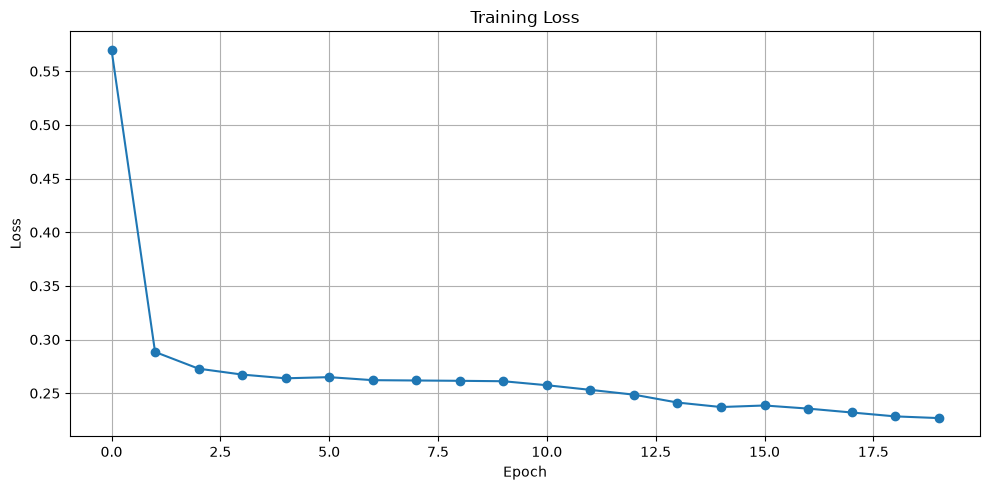

✓ Loss plot saved


In [9]:
# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(epoch_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_loss.png"))
plt.show()
print(f"✓ Loss plot saved")

In [10]:
# Test inference
context_encoder.eval()
predictor.eval()
decoder.eval()

with torch.no_grad():
    test_images, _ = next(iter(test_loader))
    test_images = test_images.to(device)
    masked_images, target_patches, mask_features = random_mask_batch(test_images, patch_size=PATCH_SIZE)
    
    context_emb = context_encoder(masked_images)
    pred_emb = predictor(context_emb, mask_features)
    pred_patches = decoder(pred_emb)
    
    print(f"✓ Test inference successful")
    print(f"  Input shape: {test_images.shape}")
    print(f"  Predicted patch shape: {pred_patches.shape}")
    print(f"  Predicted patch range: [{pred_patches.min():.3f}, {pred_patches.max():.3f}]")

✓ Test inference successful
  Input shape: torch.Size([256, 3, 32, 32])
  Predicted patch shape: torch.Size([256, 3, 8, 8])
  Predicted patch range: [-1.000, 1.000]
